## Plotting the raw synaptic metrics in heatmap across metric x hippocampal lamina
#### Input: output of `04_lmem.R`
#### Description: 
#####   (1) data frame operations
#####   (2) plotting
#### Date: Nov 2025

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

In [13]:
# Candidate to make the heatmap of
protein = "GPR37L1"

In [14]:
# order to show the metrics and hippocampal layers

metric_order = [
    "presynapse_image_mfi", 
    "pre_staining_area_um2",
    "pre_puncta_density_per_100_um2",
    "pre_mean_puncta_size_um2",
    "postsynapse_image_mfi",
    "post_staining_area_um2",
    "post_puncta_density_per_100_um2",
    "post_mean_puncta_size_um2",
    "local_peak_colocalized_spots",
    "pearson_cor",
    "overlap_coeff",
    "overlap_um2"
    ]

vglut1_hippocampal_layer_order = [
    "CA1 SO",
    "CA1 SR",
    "CA1 SLM",
    "CA3 SO",
    "CA3 SL",
    "CA3 SR",
    "DG ML",
    "DG Hilus"
    ]

vgat_hippocampal_layer_order = [
    "CA1 SO",
    "CA1 SR",
    "CA1 SLM",
    "CA3 SO",
    "CA3 SL",
    "CA3 SR",
    "DG ML",
    "DG Hilus"
    ]

In [15]:
#reading in the VGLUT1-PSD95 data
file_path_vglut1 = f"/Volumes/Intenso/image-analysis/synapse-counting/results_202512/{protein}_VGLUT1-PSD95_lmem_analysis_results.csv"
df_vglut1 = pd.read_csv(file_path_vglut1)
df_vglut1.head(10)

,hippocampal_layer,contrast,estimate,SE,df,z.ratio,p.value,Mean_GPR37L1-gRNA,Mean_LacZ-gRNA,p.value.adj,analyzed_metric,analyzed_protein
0,CA1 SLM,(GPR37L1-gRNA) - (LacZ-gRNA),0.358974,0.506791,inf,0.708328,0.478742,8.242547,7.883573,0.996714,local_peak_colocalized_spots,GPR37L1
1,CA1 SO,(GPR37L1-gRNA) - (LacZ-gRNA),-0.229423,0.506791,inf,-0.452697,0.650767,8.918606,9.148029,0.996714,local_peak_colocalized_spots,GPR37L1
2,CA1 SR,(GPR37L1-gRNA) - (LacZ-gRNA),0.012800,0.506791,inf,0.025257,0.979850,8.826618,8.813818,0.996714,local_peak_colocalized_spots,GPR37L1
3,CA3 SL,(GPR37L1-gRNA) - (LacZ-gRNA),0.468418,0.506791,inf,0.924282,0.355339,6.817227,6.348808,0.996714,local_peak_colocalized_spots,GPR37L1
4,CA3 SO,(GPR37L1-gRNA) - (LacZ-gRNA),0.571929,0.506791,inf,1.128528,0.259097,8.399010,7.827081,0.996714,local_peak_colocalized_spots,GPR37L1
5,CA3 SR,(GPR37L1-gRNA) - (LacZ-gRNA),0.276087,0.506791,inf,0.544775,0.585908,8.296333,8.020246,0.996714,local_peak_colocalized_spots,GPR37L1
6,DG Hilus,(GPR37L1-gRNA) - (LacZ-gRNA),0.002087,0.506791,inf,0.004119,0.996714,6.689732,6.687644,0.996714,local_peak_colocalized_spots,GPR37L1
7,DG ML,(GPR37L1-gRNA) - (LacZ-gRNA),0.133809,0.506791,inf,0.264033,0.791755,6.459080,6.325270,0.996714,local_peak_colocalized_spots,GPR37L1
8,CA1 SLM,(GPR37L1-gRNA) - (LacZ-gRNA),-0.017898,0.010084,inf,-1.774848,0.075923,0.338433,0.356330,0.530796,overlap_coeff,GPR37L1
9,CA1 SO,(GPR37L1-gRNA) - (LacZ-gRNA),-0.014909,0.010084,inf,-1.478458,0.139285,0.354616,0.369525,0.530796,overlap_coeff,GPR37L1


In [16]:
# get the df for adj p values
df_vglut1_adj_p_values = df_vglut1[["hippocampal_layer", "p.value.adj", "analyzed_metric"]]
df_wide_vglut1_p_value = df_vglut1_adj_p_values.pivot(index="analyzed_metric", columns="hippocampal_layer", values="p.value.adj").reindex(metric_order)
df_wide_vglut1_p_value_ordered = df_wide_vglut1_p_value[vglut1_hippocampal_layer_order]
df_wide_vglut1_p_value_ordered.head(12)

hippocampal_layer,CA1 SO,CA1 SR,CA1 SLM,CA3 SO,CA3 SL,CA3 SR,DG ML,DG Hilus
analyzed_metric,,,,,,,,
presynapse_image_mfi,0.637351,0.637351,0.701989,0.797693,0.841751,0.963184,0.797693,0.665214
pre_staining_area_um2,0.686030,0.686030,0.686030,0.848584,0.848584,0.686030,0.686030,0.848584
pre_puncta_density_per_100_um2,0.796476,0.796476,0.796476,0.796476,0.838178,0.796476,0.796476,0.838178
pre_mean_puncta_size_um2,0.609022,0.803553,0.609022,0.609022,0.609022,0.609022,0.609022,0.891487
postsynapse_image_mfi,0.828000,0.828000,0.828000,0.828000,0.828000,0.828000,0.895033,0.842508
post_staining_area_um2,0.864139,0.864139,0.739424,0.914235,0.914235,0.914235,0.864139,0.739424
post_puncta_density_per_100_um2,0.795529,0.795529,0.795529,0.795529,0.795529,0.795529,0.795529,0.795529
post_mean_puncta_size_um2,0.932636,0.932636,0.932636,0.932636,0.932636,0.932636,0.932636,0.932636
local_peak_colocalized_spots,0.996714,0.996714,0.996714,0.996714,0.996714,0.996714,0.996714,0.996714


In [17]:
# get the df for log2 fold change
df_vglut1_log2_fc = df_vglut1[["hippocampal_layer", "estimate", "analyzed_metric"]]
df_wide_vglut1_log2_fc = df_vglut1_log2_fc.pivot(index="analyzed_metric", columns="hippocampal_layer", values="estimate").reindex(metric_order)
df_wide_vglut1_log2_fc_ordered = df_wide_vglut1_log2_fc[vglut1_hippocampal_layer_order]
if protein == "VCAM1":
    df_wide_vglut1_log2_fc_ordered = -df_wide_vglut1_log2_fc_ordered
else: 
    pass
df_wide_vglut1_log2_fc_ordered.head(10)

hippocampal_layer,CA1 SO,CA1 SR,CA1 SLM,CA3 SO,CA3 SL,CA3 SR,DG ML,DG Hilus
analyzed_metric,,,,,,,,
presynapse_image_mfi,-0.183370,-0.187730,-0.121525,-0.068653,-0.043839,0.006014,-0.082782,-0.150062
pre_staining_area_um2,-0.103562,0.080634,-0.135885,0.019455,-0.039827,-0.095316,-0.106357,0.022188
pre_puncta_density_per_100_um2,-0.059041,0.056424,-0.080875,0.046298,-0.016133,-0.041727,-0.073956,0.024293
pre_mean_puncta_size_um2,-0.005615,0.001916,-0.006593,-0.003740,-0.004217,-0.004339,-0.004061,-0.000686
postsynapse_image_mfi,-0.040679,-0.052518,0.075223,0.097588,0.040267,0.081195,-0.010745,-0.027329
post_staining_area_um2,-0.070566,-0.088042,-0.142551,-0.024858,-0.011402,-0.032031,-0.064866,-0.140382
post_puncta_density_per_100_um2,-0.061336,-0.104026,-0.127187,-0.030124,-0.040039,-0.027493,-0.049485,-0.157689
post_mean_puncta_size_um2,-0.001258,0.001426,-0.002168,0.000630,0.004570,-0.000299,-0.002038,0.003638
local_peak_colocalized_spots,-0.229423,0.012800,0.358974,0.571929,0.468418,0.276087,0.133809,0.002087


In [18]:
# reading in the VGAT-GEPH dataset
vgat_results_file = f"/Volumes/Intenso/image-analysis/synapse-counting/results_202512/{protein}_VGAT-GEPH_lmem_analysis_results.csv"
df_vgat = pd.read_csv(vgat_results_file)
df_vgat.head(10)

,hippocampal_layer,contrast,estimate,SE,df,z.ratio,p.value,Mean_GPR37L1-gRNA,Mean_LacZ-gRNA,p.value.adj,analyzed_metric,analyzed_protein
0,CA1 SLM,(GPR37L1-gRNA) - (LacZ-gRNA),-1.339933,0.545620,inf,-2.455799,0.014057,6.499994,7.839926,0.112457,local_peak_colocalized_spots,GPR37L1
1,CA1 SO,(GPR37L1-gRNA) - (LacZ-gRNA),-0.305238,0.545620,inf,-0.559434,0.575865,3.821479,4.126718,0.910010,local_peak_colocalized_spots,GPR37L1
2,CA1 SR,(GPR37L1-gRNA) - (LacZ-gRNA),-0.619195,0.545620,inf,-1.134846,0.256440,3.795308,4.414503,0.512879,local_peak_colocalized_spots,GPR37L1
3,CA3 SL,(GPR37L1-gRNA) - (LacZ-gRNA),-0.214287,0.545620,inf,-0.392741,0.694511,4.323040,4.537327,0.910010,local_peak_colocalized_spots,GPR37L1
4,CA3 SO,(GPR37L1-gRNA) - (LacZ-gRNA),-0.140874,0.545620,inf,-0.258192,0.796259,5.501051,5.641925,0.910010,local_peak_colocalized_spots,GPR37L1
5,CA3 SR,(GPR37L1-gRNA) - (LacZ-gRNA),-0.642442,0.545620,inf,-1.177454,0.239015,5.984450,6.626892,0.512879,local_peak_colocalized_spots,GPR37L1
6,DG Hilus,(GPR37L1-gRNA) - (LacZ-gRNA),-0.061273,0.545620,inf,-0.112299,0.910586,4.666539,4.727812,0.910586,local_peak_colocalized_spots,GPR37L1
7,DG ML,(GPR37L1-gRNA) - (LacZ-gRNA),-0.693578,0.545620,inf,-1.271175,0.203666,5.270552,5.964130,0.512879,local_peak_colocalized_spots,GPR37L1
8,CA1 SLM,(GPR37L1-gRNA) - (LacZ-gRNA),0.004970,0.023994,inf,0.207149,0.835893,0.256173,0.251203,0.969524,overlap_coeff,GPR37L1
9,CA1 SO,(GPR37L1-gRNA) - (LacZ-gRNA),0.004307,0.023994,inf,0.179491,0.857552,0.328254,0.323947,0.969524,overlap_coeff,GPR37L1


In [19]:
# get the df with adj pvalues
df_vgat_adj_p_values = df_vgat[["hippocampal_layer", "p.value.adj", "analyzed_metric"]]
df_wide_vgat_p_value = df_vgat_adj_p_values.pivot(index="analyzed_metric", columns="hippocampal_layer", values="p.value.adj").reindex(metric_order)
df_wide_vgat_p_value_ordered = df_wide_vgat_p_value[vglut1_hippocampal_layer_order]
df_wide_vgat_p_value_ordered.head(10)

hippocampal_layer,CA1 SO,CA1 SR,CA1 SLM,CA3 SO,CA3 SL,CA3 SR,DG ML,DG Hilus
analyzed_metric,,,,,,,,
presynapse_image_mfi,0.162012,0.265803,0.113221,0.959580,0.455407,0.455407,0.265803,0.906368
pre_staining_area_um2,0.972208,0.972208,0.975957,0.972208,0.975957,0.975957,0.972208,0.972208
pre_puncta_density_per_100_um2,0.974452,0.974452,0.974452,0.974452,0.974452,0.974452,0.758446,0.974452
pre_mean_puncta_size_um2,0.887170,0.887170,0.887170,0.887170,0.887170,0.887170,0.887170,0.887170
postsynapse_image_mfi,0.693494,0.693494,0.693494,0.693494,0.693494,0.693494,0.693494,0.693494
post_staining_area_um2,0.878501,0.878501,0.878501,0.878501,0.022299,0.878501,0.878501,0.878501
post_puncta_density_per_100_um2,0.933045,0.933045,0.933045,0.933045,0.007796,0.933045,0.933045,0.933045
post_mean_puncta_size_um2,0.787488,0.787488,0.787488,0.787488,0.787488,0.869212,0.787488,0.787488
local_peak_colocalized_spots,0.910010,0.512879,0.112457,0.910010,0.910010,0.512879,0.512879,0.910586


In [20]:
# get the df with log2 fold change
df_vgat_adj_log2_fc = df_vgat[["hippocampal_layer", "estimate", "analyzed_metric"]]
df_wide_vgat_log2_fc = df_vgat_adj_log2_fc.pivot(index="analyzed_metric", columns="hippocampal_layer", values="estimate").reindex(metric_order)
df_wide_vgat_log2_fc_ordered = df_wide_vgat_log2_fc[vglut1_hippocampal_layer_order]
if protein == "VCAM1":
    df_wide_vgat_log2_fc_ordered = -df_wide_vgat_log2_fc_ordered
else: 
    pass
df_wide_vgat_log2_fc_ordered.head(10)

hippocampal_layer,CA1 SO,CA1 SR,CA1 SLM,CA3 SO,CA3 SL,CA3 SR,DG ML,DG Hilus
analyzed_metric,,,,,,,,
presynapse_image_mfi,-0.182995,-0.134238,-0.219154,-0.004527,-0.086214,-0.084959,-0.137267,-0.023433
pre_staining_area_um2,0.181482,0.174189,-0.028103,0.293948,0.010224,0.077126,0.508624,-0.197408
pre_puncta_density_per_100_um2,0.113963,0.096529,-0.038447,0.221461,-0.009169,0.066810,0.478298,-0.159601
pre_mean_puncta_size_um2,0.007533,0.007251,0.002033,0.005923,0.001552,0.001057,0.001636,-0.002519
postsynapse_image_mfi,-0.036293,-0.094013,-0.149824,0.043269,-0.044416,-0.080684,-0.077417,-0.048335
post_staining_area_um2,0.077715,-0.088653,0.200862,0.229020,-1.520172,-0.122246,-0.329314,0.167810
post_puncta_density_per_100_um2,0.135323,-0.036814,0.138536,0.146184,-1.445065,-0.098884,-0.254788,0.259105
post_mean_puncta_size_um2,-0.009899,-0.007616,0.006231,0.007459,-0.004895,-0.002014,-0.006112,-0.014987
local_peak_colocalized_spots,-0.305238,-0.619195,-1.339933,-0.140874,-0.214287,-0.642442,-0.693578,-0.061273


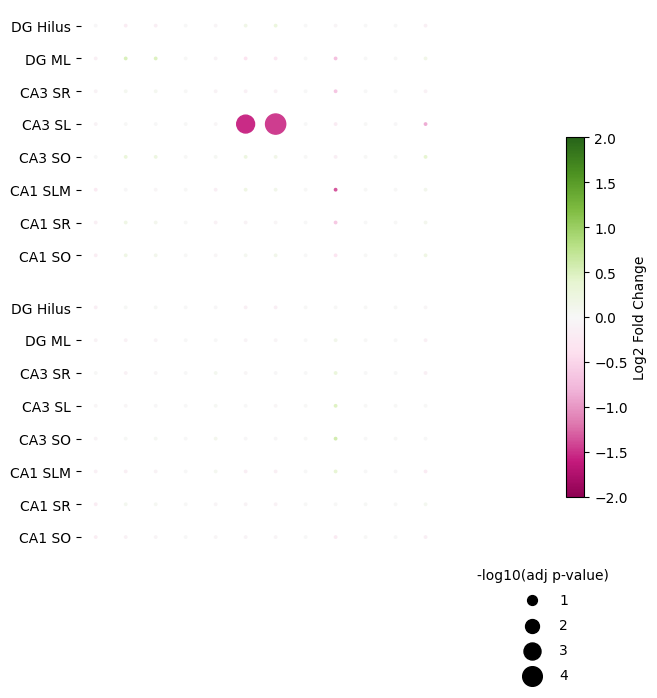

In [21]:
# Set up the figure
fig = plt.figure(figsize=(6.5, 8))

# Create a grid for the main plots and the legend
gs = fig.add_gridspec(3, 2, width_ratios=[3, 1], height_ratios=[1, 1, 0.2], hspace=0.1, wspace=0.1)

# Data and parameters for each plot
data_sets = [
    (df_wide_vgat_p_value_ordered, df_wide_vgat_log2_fc_ordered, vgat_hippocampal_layer_order),
    (df_wide_vglut1_p_value_ordered, df_wide_vglut1_log2_fc_ordered, vglut1_hippocampal_layer_order)
]
titles = ['VGAT', 'VGLUT1']

# Create subplots for the main plots
axes = [fig.add_subplot(gs[i, 0]) for i in range(2)]

for i, (ax, (df_p_value, df_log2_fc, hippocampal_layer_order)) in enumerate(zip(axes, data_sets)):
    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

    # Flatten the data
    x_vals = np.repeat(range(len(metric_order)), len(hippocampal_layer_order))
    y_vals = np.tile(range(len(hippocampal_layer_order)), len(metric_order))
    sizes = df_p_value.values.flatten()
    sizes_log = -np.log10(sizes) * 100
    colors = df_log2_fc.values.flatten()

    # Apply cutoff
    cutoff = 1
    sizes_log[sizes_log < (cutoff * 100)] = 3

    # Create scatter plot
    norm = Normalize(vmin=-2, vmax=2)
    scatter = ax.scatter(x_vals, y_vals, s=sizes_log, c=colors, cmap='PiYG', norm=norm)
    
    # Adjust x and y limits to avoid cutting off points
    ax.set_xlim(-0.5, len(metric_order) - 0.5)
    ax.set_ylim(-0.5, len(hippocampal_layer_order) - 0.5)
    
    # Set y ticks for each plot
    ax.set_yticks(range(len(hippocampal_layer_order)))
    ax.set_yticklabels(hippocampal_layer_order)

    # Only set x ticks for the bottom plot
    if i == 2:  # Bottom plot
        ax.set_xticks(range(len(metric_order)))
        ax.set_xticklabels(metric_order, rotation=90)
    else:
        ax.set_xticks([])

    # Set title for each subplot
    #ax.set_title(titles[i], y=1.0, pad=-14)

# Create a subplot for the legends
legend_ax = fig.add_subplot(gs[:, 1])
legend_ax.axis('off')

# Add a colorbar
cbar = fig.colorbar(scatter, ax=legend_ax, shrink=0.8, aspect=20, pad=0.05)
cbar.set_label("Log2 Fold Change")

# Create a legend for dot sizes
size_legend_labels = [1, 2, 3, 4]
size_legend = [plt.scatter([], [], s=size*50, edgecolor='black', facecolor='black') for size in size_legend_labels]
legend_ax.legend(size_legend, [f'{label}' for label in size_legend_labels],
                 title='-log10(adj p-value)', loc='center left', bbox_to_anchor=(0, 0),
                 handletextpad=1, labelspacing=0.8, frameon=False)



#plt.savefig(f"/Volumes/KINGSTON/data/phd/image-analysis/synapse-counting/{protein}_dotplot", dpi=600, bbox_inches = "tight")
#plt.tight_layout()
plt.show()

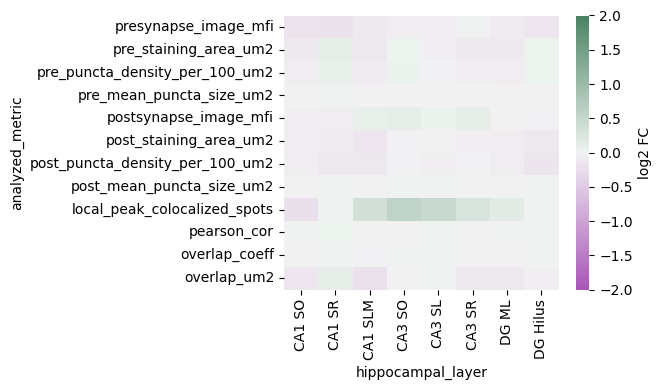

In [22]:
fig, ax = plt.subplots(figsize=(6.5, 4))
sns.heatmap(df_wide_vglut1_log2_fc_ordered, 
            cmap= sns.diverging_palette(300, 145, s=60, as_cmap=True),  
            center=0,  
            annot=False,  
            cbar_kws={'label': 'log2 FC'},
            ax=ax,
            vmin=-2,
            vmax=2)

significance_threshold = 0.05


for i in range(df_wide_vglut1_p_value_ordered.shape[0]):
    for j in range(df_wide_vglut1_p_value_ordered.shape[1]):
        if df_wide_vglut1_p_value_ordered.iloc[i, j] < significance_threshold:  # Use .iloc for DataFrame
            ax.text(j + 0.5, i + 0.7, '*',
                   ha='center', va='center',
                   color='black', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{protein}_vglut1_heatmap_plot.svg", format='svg')
plt.show()

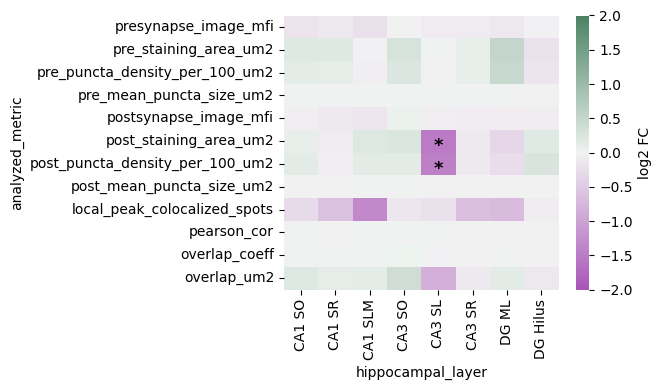

In [23]:
fig, ax = plt.subplots(figsize=(6.5, 4))
sns.heatmap(df_wide_vgat_log2_fc_ordered, 
            cmap=sns.diverging_palette(300, 145, s=60, as_cmap=True),  
            center=0,  
            annot=False,  
            cbar_kws={'label': 'log2 FC'},
            ax=ax,
            vmin=-2,
            vmax=2)

significance_threshold = 0.05

for i in range(df_wide_vgat_p_value_ordered.shape[0]):
    for j in range(df_wide_vgat_p_value_ordered.shape[1]):
        if df_wide_vgat_p_value_ordered.iloc[i, j] < significance_threshold:  # Use .iloc for DataFrame
            ax.text(j + 0.5, i + 0.7, '*',
                   ha='center', va='center',
                   color='black', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{protein}_vgat_heatmap_plot.svg", format='svg')
plt.show()
